In [86]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import random
import pandas as pd
import seaborn as sns

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [87]:

print(np.__version__)


1.26.4


In [88]:
# Map images to their class labels for model training
from torchvision import datasets

dataset_path = "/Users/alimran/Desktop/CSE499A/Dataset"

# Use ImageFolder to automatically map images to class indices
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)

# Show the mapping of class names to indices
print("Class to index mapping:", dataset.class_to_idx)

# Show a few sample image paths and their mapped class labels
for i in range(5):
    img_path, label = dataset.samples[i]
    print(f"Image: {img_path} => Class: {dataset.classes[label]}")


Class to index mapping: {'Guava_Anthracnose': 0, 'Guava_Healthy': 1, 'Mango_Anthracnose': 2, 'Mango_Healthy': 3, 'Papaya_Anthracnose': 4, 'Papaya_Healthy': 5}
Image: /Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (1).jpg => Class: Guava_Anthracnose
Image: /Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (10).jpg => Class: Guava_Anthracnose
Image: /Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (100).jpg => Class: Guava_Anthracnose
Image: /Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (101).jpg => Class: Guava_Anthracnose
Image: /Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (102).jpg => Class: Guava_Anthracnose


In [89]:
# Show info for class 0
class_0_name = dataset.classes[0]
print(f"Class 0 name: {class_0_name}")

# Get all image paths for class 0
class_0_images = [img_path for img_path, label in dataset.samples if label == 0]
print(f"Number of images in class 0: {len(class_0_images)}")
print("Sample image paths for class 0:")
for img_path in class_0_images[:5]:
    print(img_path)

Class 0 name: Guava_Anthracnose
Number of images in class 0: 237
Sample image paths for class 0:
/Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (1).jpg
/Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (10).jpg
/Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (100).jpg
/Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (101).jpg
/Users/alimran/Desktop/CSE499A/Dataset/Guava_Anthracnose/Anthracnose (102).jpg


In [90]:
class LeafDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.plant_labels = []
        self.health_labels = []

        for class_folder in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_folder)
            if not os.path.isdir(class_path):
                continue

            if "Mango" in class_folder:
                plant_label = 0
            elif "Papaya" in class_folder:
                plant_label = 1
            elif "Guava" in class_folder:
                plant_label = 2
            else:
                plant_label = 3

            if "Healthy" in class_folder:
                health_label = 0
            else:
                health_label = 1

            for img_file in os.listdir(class_path):
                if img_file.endswith(('.jpg', '.png', '.jpeg')):
                    self.image_paths.append(os.path.join(class_path, img_file))
                    self.plant_labels.append(plant_label)
                    self.health_labels.append(health_label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.plant_labels[idx], self.health_labels[idx]


In [91]:
full_dataset = LeafDataset(root_dir=dataset_path, transform=None)

indices = list(range(len(full_dataset)))
random.shuffle(indices)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

# Assign transforms explicitly
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform

print("Total images:", len(full_dataset))
print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

Total images: 3268
Train samples: 2614, Validation samples: 654


In [92]:
plant_names = ["Mango", "Papaya", "Guava"]
health_names = ["Healthy", "Anthracnose"]

# Prepare DataFrame
df = pd.DataFrame({
    'plant': [plant_names[p] for p in full_dataset.plant_labels],
    'health': [health_names[h] for h in full_dataset.health_labels]
})

# Count
plant_counts = df['plant'].value_counts()
health_counts = df['health'].value_counts()
combined_counts = df.groupby(['plant', 'health']).size().reset_index(name='count')

print("\nPlant distribution:\n", plant_counts)
print("\nHealth distribution:\n", health_counts)
print("\nCombined distribution:\n", combined_counts)



Plant distribution:
 plant
Guava     1485
Mango     1200
Papaya     583
Name: count, dtype: int64

Health distribution:
 health
Healthy        2076
Anthracnose    1192
Name: count, dtype: int64

Combined distribution:
     plant       health  count
0   Guava  Anthracnose    237
1   Guava      Healthy   1248
2   Mango  Anthracnose    600
3   Mango      Healthy    600
4  Papaya  Anthracnose    355
5  Papaya      Healthy    228


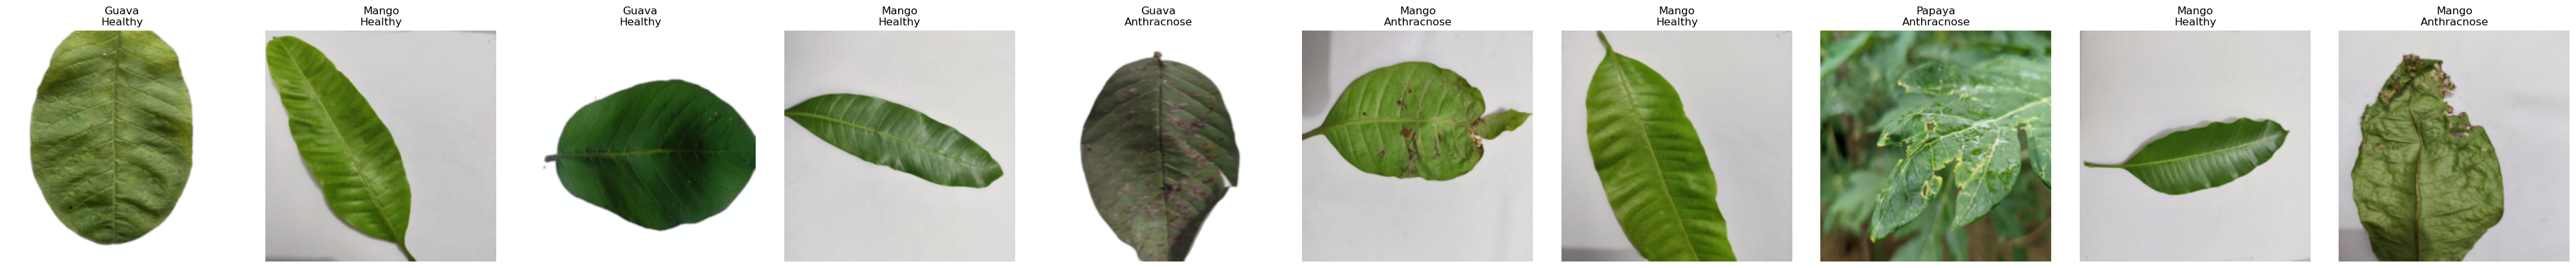

In [93]:
def plot_random_samples(dataset, n):
    indices = random.sample(range(len(dataset)), n)
    plt.figure(figsize=(4 * n, 4))
    for i, idx in enumerate(indices):
        img, plant_label, health_label = dataset[idx]
        img = img.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        title = f"{plant_names[plant_label]}\n{health_names[health_label]}"
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_random_samples(full_dataset, n=10)


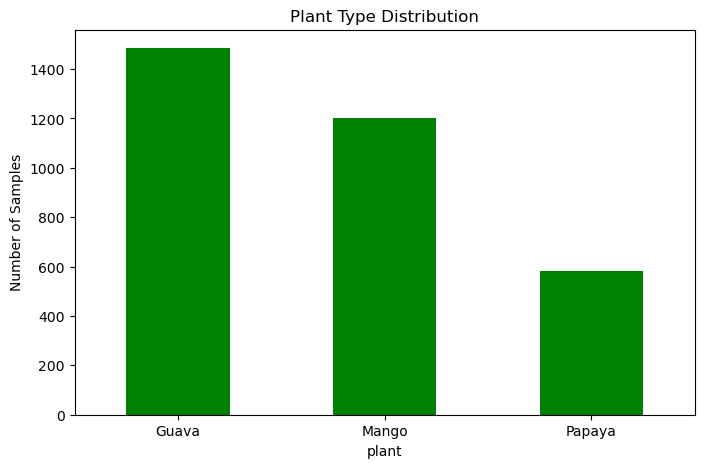

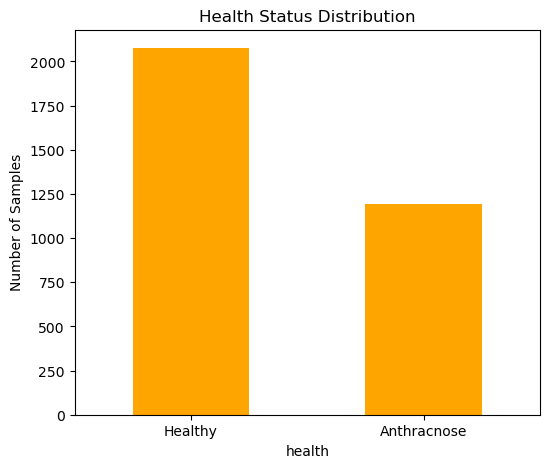

In [94]:
plt.figure(figsize=(8, 5))
plant_counts.plot(kind='bar', color='green', title='Plant Type Distribution')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6, 5))
health_counts.plot(kind='bar', color='orange', title='Health Status Distribution')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()


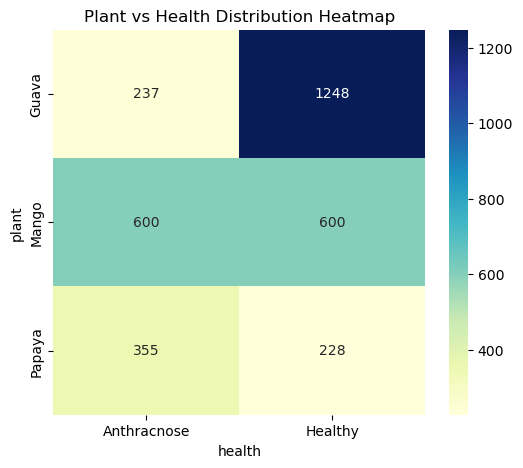

In [95]:
combined_pivot = df.groupby(['plant', 'health']).size().unstack(fill_value=0)

plt.figure(figsize=(6, 5))
sns.heatmap(combined_pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Plant vs Health Distribution Heatmap")
plt.show()


In [96]:
import torch.nn as nn
import torchvision.models as models

class DualHeadResNet(nn.Module):
    def __init__(self, num_plant_classes=3, num_health_classes=2):
        super(DualHeadResNet, self).__init__()
        self.backbone = models.resnet18(pretrained=True)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.dropout = nn.Dropout(0.5)  # ADD DROPOUT

        self.plant_head = nn.Linear(num_features, num_plant_classes)
        self.health_head = nn.Linear(num_features, num_health_classes)

    def forward(self, x):
        features = self.backbone(x)
        features = self.dropout(features)  # Apply dropout
        plant_output = self.plant_head(features)
        health_output = self.health_head(features)
        return plant_output, health_output


In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DualHeadResNet(num_plant_classes=3, num_health_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


/opt/anaconda3/envs/CSE499A_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/CSE499A_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
num_epochs = 10
train_losses, val_losses = [], []
train_plant_accs, val_plant_accs = [], []
train_health_accs, val_health_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct_plant, correct_health, total = 0, 0, 0, 0

    for images, plant_labels, health_labels in train_loader:
        images = images.to(device)
        plant_labels = plant_labels.to(device)
        health_labels = health_labels.to(device)

        optimizer.zero_grad()
        outputs_plant, outputs_health = model(images)

        loss_plant = criterion(outputs_plant, plant_labels)
        loss_health = criterion(outputs_health, health_labels)
        loss = loss_plant + loss_health

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted_plant = torch.max(outputs_plant, 1)
        _, predicted_health = torch.max(outputs_health, 1)

        correct_plant += (predicted_plant == plant_labels).sum().item()
        correct_health += (predicted_health == health_labels).sum().item()
        total += images.size(0)

    train_loss = running_loss / total
    train_plant_acc = correct_plant / total
    train_health_acc = correct_health / total
# Validation
    model.eval()
    val_running_loss, val_correct_plant, val_correct_health, val_total = 0, 0, 0, 0
    all_plant_true, all_plant_pred, all_health_true, all_health_pred = [], [], [], []

    with torch.no_grad():
        for images, plant_labels, health_labels in val_loader:
            images = images.to(device)
            plant_labels = plant_labels.to(device)
            health_labels = health_labels.to(device)

            outputs_plant, outputs_health = model(images)
            loss_plant = criterion(outputs_plant, plant_labels)
            loss_health = criterion(outputs_health, health_labels)
            loss = loss_plant + loss_health

            val_running_loss += loss.item() * images.size(0)
            _, predicted_plant = torch.max(outputs_plant, 1)
            _, predicted_health = torch.max(outputs_health, 1)

            val_correct_plant += (predicted_plant == plant_labels).sum().item()
            val_correct_health += (predicted_health == health_labels).sum().item()
            val_total += images.size(0)
            all_plant_true.extend(plant_labels.cpu().numpy())
            all_plant_pred.extend(predicted_plant.cpu().numpy())
            all_health_true.extend(health_labels.cpu().numpy())
            all_health_pred.extend(predicted_health.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_plant_acc = val_correct_plant / val_total
    val_health_acc = val_correct_health / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_plant_accs.append(train_plant_acc)
    val_plant_accs.append(val_plant_acc)
    train_health_accs.append(train_health_acc)
    val_health_accs.append(val_health_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Train Plant Acc: {train_plant_acc:.4f}, Val Plant Acc: {val_plant_acc:.4f}, "
          f"Train Health Acc: {train_health_acc:.4f}, Val Health Acc: {val_health_acc:.4f}")

print("Training complete!")

Epoch [1/10] Train Loss: 0.3985, Val Loss: 0.2766, Train Plant Acc: 0.9809, Val Plant Acc: 0.9709, Train Health Acc: 0.8711, Val Health Acc: 0.9266
Epoch [2/10] Train Loss: 0.3598, Val Loss: 0.2142, Train Plant Acc: 0.9782, Val Plant Acc: 0.9908, Train Health Acc: 0.8948, Val Health Acc: 0.9465
Epoch [3/10] Train Loss: 0.2043, Val Loss: 0.0708, Train Plant Acc: 0.9966, Val Plant Acc: 0.9985, Train Health Acc: 0.9308, Val Health Acc: 0.9771
Epoch [4/10] Train Loss: 0.1923, Val Loss: 0.1650, Train Plant Acc: 0.9958, Val Plant Acc: 0.9587, Train Health Acc: 0.9411, Val Health Acc: 0.9832
Epoch [5/10] Train Loss: 0.1594, Val Loss: 0.1303, Train Plant Acc: 0.9996, Val Plant Acc: 0.9924, Train Health Acc: 0.9441, Val Health Acc: 0.9587
Epoch [6/10] Train Loss: 0.1356, Val Loss: 0.0651, Train Plant Acc: 0.9977, Val Plant Acc: 0.9969, Train Health Acc: 0.9529, Val Health Acc: 0.9878
Epoch [7/10] Train Loss: 0.1077, Val Loss: 0.1490, Train Plant Acc: 0.9996, Val Plant Acc: 0.9969, Train Health 

In [ ]:
torch.save(model.state_dict(), "dualhead_leaf_model.pth")
print("Model saved!")

✅ Model saved!


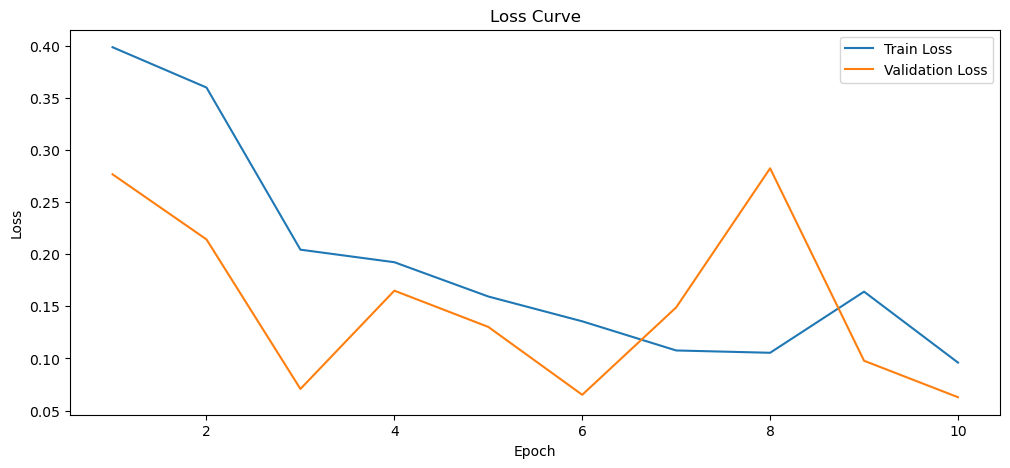

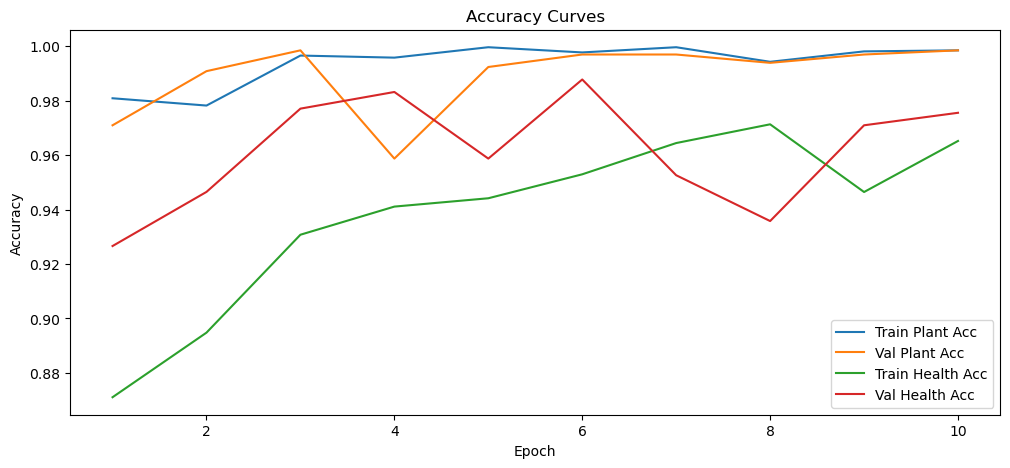

In [100]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(epochs, train_plant_accs, label='Train Plant Acc')
plt.plot(epochs, val_plant_accs, label='Val Plant Acc')
plt.plot(epochs, train_health_accs, label='Train Health Acc')
plt.plot(epochs, val_health_accs, label='Val Health Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

In [101]:
plant_names = ["Mango Leaf", "Papaya Leaf", "Guava Leaf", "Other Leaf"]
health_names = ["Healthy Leaf", "Anthracnose Diseased"]

def predict_image(model, image_path, transform, device='cpu'):
    image = Image.open(image_path).convert("RGB")
    image_transformed = transform(image).unsqueeze(0)
    image_transformed = image_transformed.to(device)
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        output_plant, output_health = model(image_transformed)
        _, pred_plant = torch.max(output_plant, 1)
        _, pred_health = torch.max(output_health, 1)

    plant_label = plant_names[pred_plant.item()]
    health_label = health_names[pred_health.item()]
    img_disp = np.array(image)
    plt.imshow(img_disp)
    plt.title(f"Predicted: {plant_label}, {health_label}")
    plt.axis('off')
    plt.show()

    print(f"Predicted Plant Type: {plant_label}")
    print(f"Predicted Health Status: {health_label}")


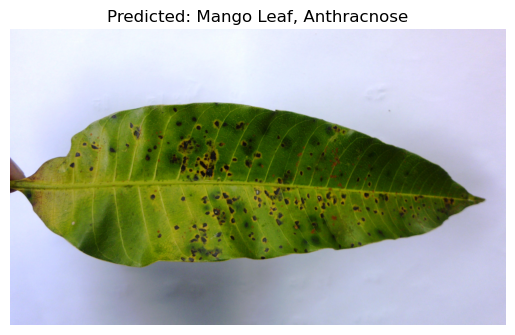

Predicted Plant Type: Mango Leaf
Predicted Health Status: Anthracnose


In [119]:
test_image_path = "/Users/alimran/Desktop/anthracnose-of-mango-bangladesh-2.jpg"  # Change to your test image
predict_image(model, test_image_path, val_test_transform)

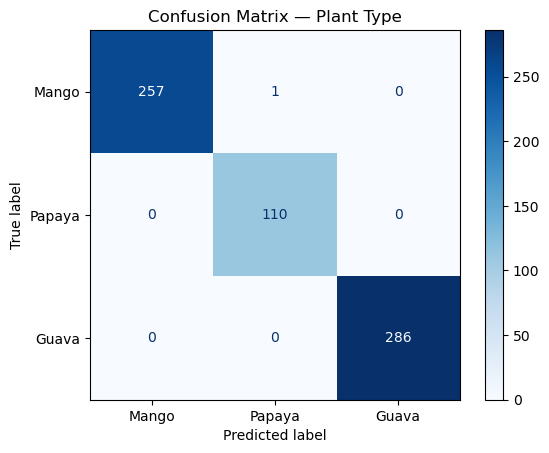

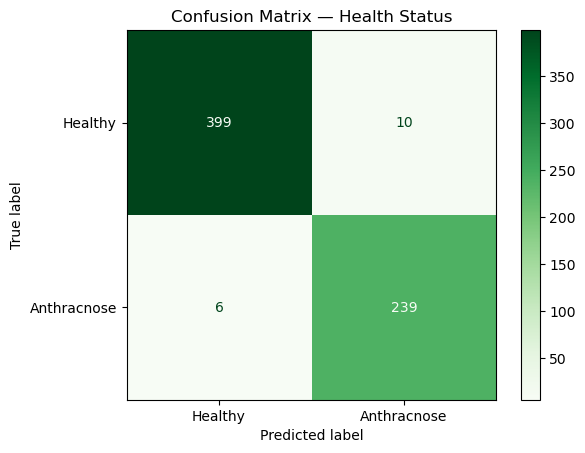

In [109]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plant_names_all = ["Mango", "Papaya", "Guava", "Other"]

unique_labels = sorted(list(set(all_plant_true + all_plant_pred)))
plant_names_filtered = [plant_names_all[i] for i in unique_labels]

cm_plant = confusion_matrix(all_plant_true, all_plant_pred)
disp_plant = ConfusionMatrixDisplay(confusion_matrix=cm_plant, display_labels=plant_names_filtered)
disp_plant.plot(cmap="Blues")
plt.title("Confusion Matrix — Plant Type")
plt.show()

health_names = ["Healthy", "Anthracnose"]

cm_health = confusion_matrix(all_health_true, all_health_pred)
disp_health = ConfusionMatrixDisplay(confusion_matrix=cm_health, display_labels=health_names)
disp_health.plot(cmap="Greens")
plt.title("Confusion Matrix — Health Status")
plt.show()

In [105]:
test_loader = val_loader
model.eval()
test_loss = 0.0
correct_plant = 0
correct_health = 0
total = 0

all_plant_true = []
all_plant_pred = []
all_health_true = []
all_health_pred = []

with torch.no_grad():
    for images, plant_labels, health_labels in test_loader:
        images = images.to(device)
        plant_labels = plant_labels.to(device)
        health_labels = health_labels.to(device)

        outputs_plant, outputs_health = model(images)

        loss_plant = criterion(outputs_plant, plant_labels)
        loss_health = criterion(outputs_health, health_labels)
        loss = loss_plant + loss_health

        test_loss += loss.item() * images.size(0)

        _, predicted_plant = torch.max(outputs_plant, 1)
        _, predicted_health = torch.max(outputs_health, 1)

        correct_plant += (predicted_plant == plant_labels).sum().item()
        correct_health += (predicted_health == health_labels).sum().item()
        total += images.size(0)

        all_plant_true.extend(plant_labels.cpu().numpy())
        all_plant_pred.extend(predicted_plant.cpu().numpy())
        all_health_true.extend(health_labels.cpu().numpy())
        all_health_pred.extend(predicted_health.cpu().numpy())

avg_test_loss = test_loss / total
test_plant_acc = correct_plant / total
test_health_acc = correct_health / total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Plant Accuracy: {test_plant_acc:.4f}")
print(f"Test Health Accuracy: {test_health_acc:.4f}")


Test Loss: 0.0628
Test Plant Accuracy: 0.9985
Test Health Accuracy: 0.9755


In [112]:
from sklearn.metrics import classification_report

# Plant type
plant_names_all = ["Mango", "Papaya", "Guava", "Other"]

# Get unique plant labels actually present in your data
unique_labels = sorted(list(set(all_plant_true + all_plant_pred)))
plant_names_filtered = [plant_names_all[i] for i in unique_labels]

# Generate report
plant_report = classification_report(all_plant_true, all_plant_pred, target_names=plant_names_filtered, digits=4)
print("=== Plant Type Classification Report ===")
print(plant_report)


=== Plant Type Classification Report ===
              precision    recall  f1-score   support

       Mango     1.0000    0.9961    0.9981       258
      Papaya     0.9910    1.0000    0.9955       110
       Guava     1.0000    1.0000    1.0000       286

    accuracy                         0.9985       654
   macro avg     0.9970    0.9987    0.9978       654
weighted avg     0.9985    0.9985    0.9985       654



In [113]:
# Health status
health_names = ["Healthy", "Anthracnose"]

health_report = classification_report(all_health_true, all_health_pred, target_names=health_names, digits=4)
print("=== Health Status Classification Report ===")
print(health_report)


=== Health Status Classification Report ===
              precision    recall  f1-score   support

     Healthy     0.9852    0.9756    0.9803       409
 Anthracnose     0.9598    0.9755    0.9676       245

    accuracy                         0.9755       654
   macro avg     0.9725    0.9755    0.9740       654
weighted avg     0.9757    0.9755    0.9756       654

